In [7]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [29]:
df = pd.read_csv("Mentors_Dataset.csv", sep=";")

In [9]:
df.head()

,MentorID,Name,JobTitle,Category,Skills,YearsExperience,Availability,Salary
0,1,Dr. Soad Hassan,Site Reliability Engineer,DevOps & Cloud,"CRI-O, CircleCI, Podman, Jenkins",6,Consulting,28000
1,2,Prof. Samir Abdel Latif,Accessibility Test Engineer,Quality Assurance,"TDD, Paw, BDD, WebDriverIO, REST Assured",2,Open to Opportunities,6000
2,3,Eng. Nour Hegazy,Smart Contract Developer,Blockchain & Web3,"Leadership, Problem Solving, Communication, Project Management, Teamwork",11,Partially Available,41000
3,4,Prof. Hala Ibrahim,iOS Developer,Mobile Development,"Swift, Retrofit, Detox, Maestro",2,Busy,10000
4,5,Eng. Essam El Sayed,MEAN Stack Developer,Full Stack Development,"Project Management, Leadership, Communication, Teamwork, Problem Solving",2,Consulting,8000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   MentorID         1000 non-null   int64 
 1   Name             1000 non-null   object
 2   JobTitle         1000 non-null   object
 3   Category         1000 non-null   object
 4   Skills           1000 non-null   object
 5   YearsExperience  1000 non-null   int64 
 6   Availability     1000 non-null   object
 7   Salary           1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
df.isnull().sum()

,0
MentorID,0
Name,0
JobTitle,0
Category,0
Skills,0
YearsExperience,0
Availability,0
Salary,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [30]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

for col in num_cols:
    outliers = detect_outliers_iqr(df, col)
    print(f"Column: {col} - Found {len(outliers)} outliers")

Column: MentorID - Found 0 outliers
Column: YearsExperience - Found 0 outliers
Column: Salary - Found 0 outliers


In [14]:
import re
import spacy
nlp = spacy.load("en_core_web_sm")

In [31]:
def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s,]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def preprocess_text(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(tokens)

In [32]:
def clean_skills(skills_input):
    if skills_input is None:
        return []
    if isinstance(skills_input, float) and pd.isna(skills_input):
        return []

    skills = []

    if isinstance(skills_input, str):
        skills = re.split(r"\s*,\s*", skills_input.lower().strip())

    elif isinstance(skills_input, list):
        skills = [str(s).lower().strip() for s in skills_input]

    skills = list(set(skills))
    corrections = {
        "kubernets": "kubernetes",
        "cicd": "ci/cd",
        "jenkin": "jenkins"
    }
    skills = [corrections.get(s, s) for s in skills if s]

    return skills


def normalize_availability(val):
    val = val.lower().strip()
    if "full" in val: return "full_time"
    if "part" in val: return "part_time"
    if "contract" in val: return "contract"
    return "unavailable"

In [33]:
df["JobTitle"] = df["JobTitle"].apply(clean_text).apply(preprocess_text)
df["Category"] = df["Category"].apply(clean_text).apply(preprocess_text)
df["Skills"] = df["Skills"].apply(clean_skills)
df["Availability"] = df["Availability"].apply(normalize_availability)

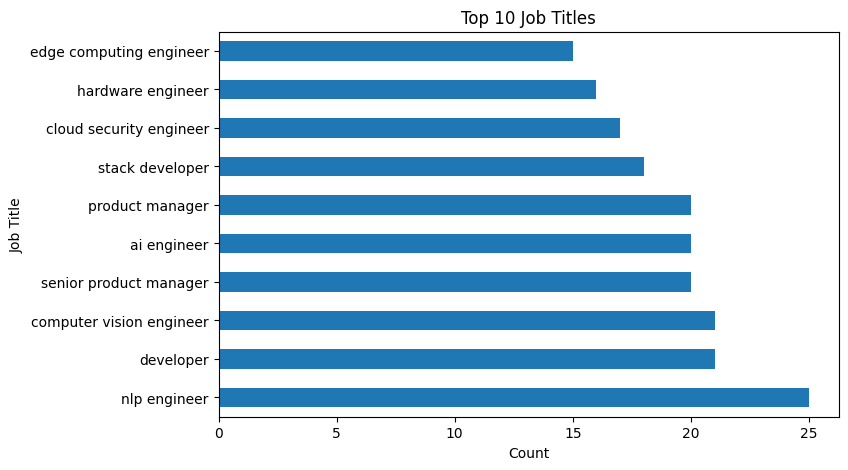

In [34]:
import matplotlib.pyplot as plt
df["JobTitle"].value_counts().head(10).plot(kind="barh", figsize=(8,5))
plt.title("Top 10 Job Titles")
plt.xlabel("Count")
plt.ylabel("Job Title")
plt.show()

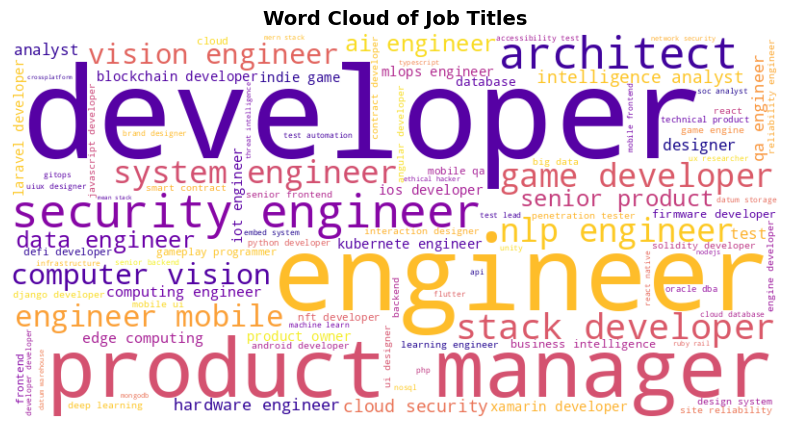

In [19]:
from wordcloud import WordCloud
text = " ".join(df["JobTitle"].dropna().astype(str).tolist())

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='plasma', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles', fontsize=14, fontweight='bold')
plt.show()


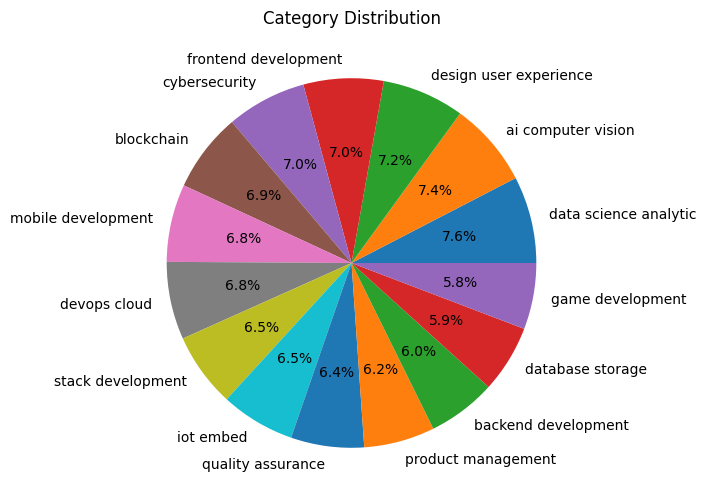

In [20]:
df["Category"].value_counts().plot(kind="pie", autopct='%1.1f%%', figsize=(6,6))
plt.title("Category Distribution")
plt.ylabel("")
plt.show()

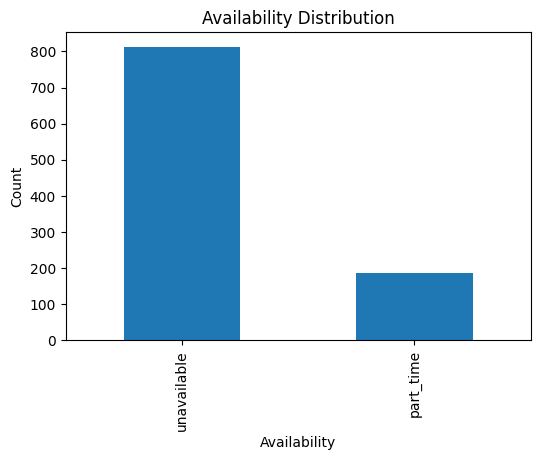

In [21]:
df["Availability"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Availability Distribution")
plt.xlabel("Availability")
plt.ylabel("Count")
plt.show()

In [35]:
def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    doc = nlp(text.lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return " ".join(tokens)

In [36]:
df["JobTitle"] = df["JobTitle"].apply(preprocess_text)
df["Category"] = df["Category"].apply(preprocess_text)

In [39]:
def build_profile(row):
    Name = row.get("Name", "").strip().lower()
    job_title = row.get("JobTitle", "").strip().lower()
    category = row.get("Category", "").strip().lower()
    skills = row.get("Skills", [])
    if isinstance(skills, list):
        skills_str = ", ".join(skills)
    else:
        skills_str = str(skills).lower().strip()

    experience = str(row.get("Experience", "")).lower().replace("years", "").strip()
    salary = str(row.get("Salary", "")).lower().replace("dollars", "").strip()
    availability = str(row.get("Availability", "")).strip().lower()

    salary_numeric = float(salary)
    mentorship_rate = salary_numeric / 160

    profile = (
    f"{Name} is a {job_title} with {experience} years of experience in {category}. "
    f"They have developed strong skills in {skills_str}, and are passionate about sharing their knowledge with others. "
    f"As a mentor, {Name.split()[0]} is currently {availability} to guide and support learners. "
    f"Their mentorship rate is ${mentorship_rate} USD."
    )

    return profile

In [40]:
df["MentorProfile"] = df.apply(build_profile, axis=1)

In [41]:
print(df["MentorProfile"].iloc[0] , )

dr. soad hassan is a site reliability engineer with  years of experience in devops cloud. They have developed strong skills in cri-o, podman, circleci, jenkins, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $175.0 USD.


In [42]:
df.head()

,MentorID,Name,JobTitle,Category,Skills,YearsExperience,Availability,Salary,MentorProfile
0,1,Dr. Soad Hassan,site reliability engineer,devops cloud,"[cri-o, podman, circleci, jenkins]",6,unavailable,28000,"dr. soad hassan is a site reliability engineer with years of experience in devops cloud. They have developed strong skills in cri-o, podman, circleci, jenkins, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $175.0 USD."
1,2,Prof. Samir Abdel Latif,accessibility test engineer,quality assurance,"[tdd, bdd, rest assured, webdriverio, paw]",2,unavailable,6000,"prof. samir abdel latif is a accessibility test engineer with years of experience in quality assurance. They have developed strong skills in tdd, bdd, rest assured, webdriverio, paw, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently unavailable to guide and support learners. Their mentorship rate is $37.5 USD."
2,3,Eng. Nour Hegazy,smart contract developer,blockchain,"[communication, leadership, teamwork, project management, problem solving]",11,part_time,41000,"eng. nour hegazy is a smart contract developer with years of experience in blockchain. They have developed strong skills in communication, leadership, teamwork, project management, problem solving, and are passionate about sharing their knowledge with others. As a mentor, eng. is currently part_time to guide and support learners. Their mentorship rate is $256.25 USD."
3,4,Prof. Hala Ibrahim,ios developer,mobile development,"[detox, retrofit, maestro, swift]",2,unavailable,10000,"prof. hala ibrahim is a ios developer with years of experience in mobile development. They have developed strong skills in detox, retrofit, maestro, swift, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently unavailable to guide and support learners. Their mentorship rate is $62.5 USD."
4,5,Eng. Essam El Sayed,mean stack developer,stack development,"[communication, leadership, teamwork, project management, problem solving]",2,unavailable,8000,"eng. essam el sayed is a mean stack developer with years of experience in stack development. They have developed strong skills in communication, leadership, teamwork, project management, problem solving, and are passionate about sharing their knowledge with others. As a mentor, eng. is currently unavailable to guide and support learners. Their mentorship rate is $50.0 USD."


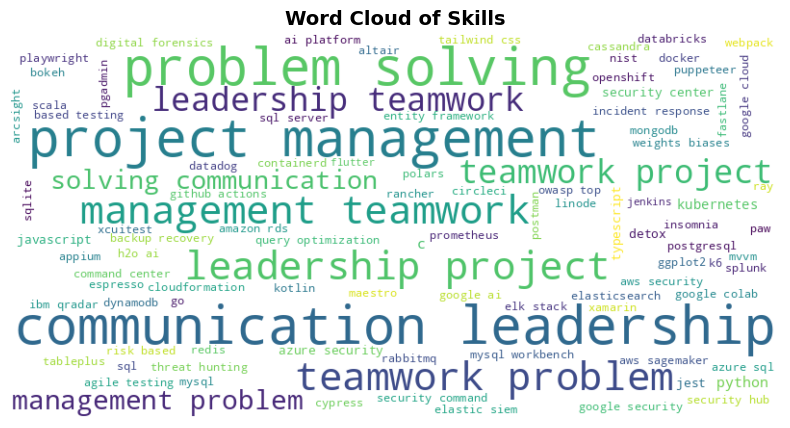

In [43]:
all_skills = df["Skills"].explode().dropna().tolist()
text = " ".join(all_skills)

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Skills', fontsize=14, fontweight='bold')
plt.show()


In [44]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [45]:
embeddings = model.encode(df["MentorProfile"].tolist(), show_progress_bar=True)

print(embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

(1000, 384)


In [51]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

student_query = "I want a mentor with AI and Python skills"
query_embedding = model.encode([student_query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = np.argsort(similarities)[::-1][:10]

df.iloc[top_indices][["MentorProfile"]]


,MentorProfile
309,"eng. ahmed nasser is a python developer with years of experience in backend development. They have developed strong skills in python, activerecord, eloquent, postgresql, and are passionate about sharing their knowledge with others. As a mentor, eng. is currently unavailable to guide and support learners. Their mentorship rate is $37.5 USD."
879,"prof. omar abdel nasser is a mlops engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, project management, teamwork, problem solving, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently part_time to guide and support learners. Their mentorship rate is $268.75 USD."
285,"prof. sama al rashid is a ai engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, project management, teamwork, problem solving, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently unavailable to guide and support learners. Their mentorship rate is $100.0 USD."
954,"dr. amal mansour is a nlp engineer with years of experience in data science analytic. They have developed strong skills in scikit-learn, sql, aws sagemaker, google ai platform, tensorflow, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $168.75 USD."
637,"prof. karim el shamy is a mlops engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, teamwork, project management, problem solving, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently unavailable to guide and support learners. Their mentorship rate is $62.5 USD."
202,"dr. aisha abdel majid is a big data engineer with years of experience in data science analytic. They have developed strong skills in sql, google ai platform, matplotlib, h2o.ai, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $262.5 USD."
78,"dr. rawya el hadidy is a ai engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, project management, teamwork, problem solving, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $181.25 USD."
168,"dr. youssef el guindy is a ai engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, project management, teamwork, problem solving, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $37.5 USD."
803,"prof. mona ahmed is a computer vision engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, project management, teamwork, problem solving, and are passionate about sharing their knowledge with others. As a mentor, prof. is currently unavailable to guide and support learners. Their mentorship rate is $87.5 USD."
513,"dr. nabil iskandar is a ai research engineer with years of experience in ai computer vision. They have developed strong skills in communication, leadership, teamwork, project management, problem solving, and are passionate about sharing their knowledge with others. As a mentor, dr. is currently unavailable to guide and support learners. Their mentorship rate is $125.0 USD."
